Load Dataset

In [ ]:
import pandas as pd

df = pd.read_csv('/content/Telecom churn analysis.csv')

View First 5 Rows

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Tenure,PhoneService,MultipleLines,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,0,1,0,2,29.85,29.85,0
1,5575-GNVDE,1,0,34,1,0,1,1,3,56.95,1889.50,0
2,3668-QPYBK,1,0,2,1,0,1,0,3,53.85,108.15,1
3,7795-CFOCW,1,0,45,0,0,1,1,0,42.30,1840.75,0
4,9237-HQITU,0,0,2,1,0,2,0,2,70.70,151.65,1


Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
Contract,0
PaymentMethod,0
MonthlyCharges,0


Convert TotalCharges to Numeric

In [ ]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(inplace=True)

Churn Distribution

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0,5147
1,1864


Churn rate:

In [ ]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.413208
1,26.586792


Average Monthly Charges

In [ ]:
df.groupby("Churn")["MonthlyCharges"].mean()

,MonthlyCharges
Churn,
0,61.302856
1,74.451448


Tenure vs Churn

In [ ]:
df.groupby("Churn")["Tenure"].mean()

,Tenure
Churn,
0,37.658830
1,17.979077


Churn by Contract Type

In [ ]:
df.groupby("Contract")["Churn"].value_counts()

Contract  Churn
0         0        2211
          1        1651
1         0        1302
          1         165
2         0        1634
          1          48
Name: count, dtype: int64

Customers with High Monthly Charges

In [ ]:
df[df["MonthlyCharges"] > 100]

,customerID,gender,SeniorCitizen,Tenure,PhoneService,MultipleLines,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
8,7892-POOKP,0,0,28,1,1,2,0,2,104.80,3046.05,1
12,8091-TTVAX,1,0,58,1,1,2,1,1,100.35,5681.10,0
13,0280-XJGEX,1,0,49,1,1,2,0,0,103.70,5036.30,1
14,5129-JLPIS,1,0,25,1,0,2,0,2,105.50,2686.05,0
15,3655-SNQYZ,0,0,69,1,1,2,2,1,113.25,7895.15,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6981,0218-QNVAS,1,0,71,1,1,2,1,0,100.55,7113.75,0
6991,9586-JGQKH,0,0,64,1,1,2,2,0,105.40,6794.75,0
6995,0093-XWZFY,1,0,40,1,1,2,0,1,104.50,4036.85,1
7007,2234-XADUH,0,0,72,1,1,2,1,1,103.20,7362.90,0


Visualization

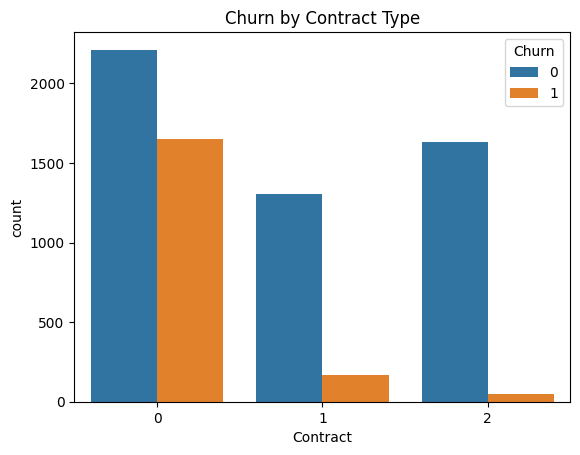

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.show()

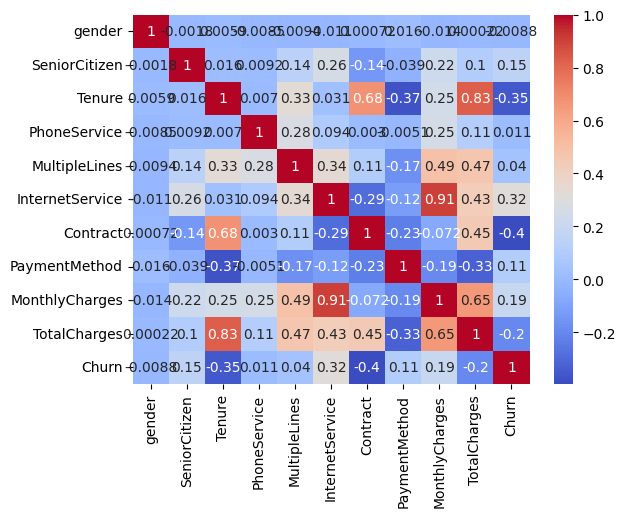

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()